In [ ]:
import os
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Parthvi code
df=pd.read_csv("/content/Students Social Media Addiction (1).csv")
df.head(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


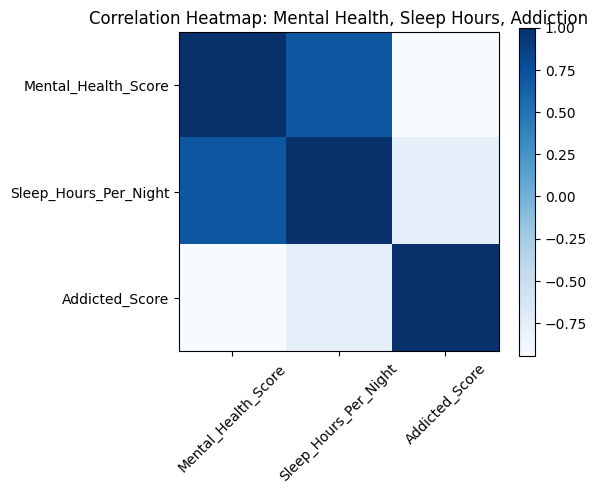

In [ ]:
#df = pd.DataFrame(data)

# Select the three variables for correlation
cols = ["Mental_Health_Score", "Sleep_Hours_Per_Night", "Addicted_Score"]
corr = df[cols].corr()

# Plot heatmap using matplotlib
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='Blues')
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.colorbar()
plt.title("Correlation Heatmap: Mental Health, Sleep Hours, Addiction")

plt.tight_layout()
plt.show()

Correlation matrix:
                        Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
Avg_Daily_Usage_Hours               1.000000              -0.790582   
Sleep_Hours_Per_Night              -0.790582               1.000000   
Mental_Health_Score                -0.801058               0.707439   
Addicted_Score                      0.832000              -0.764858   

                       Mental_Health_Score  Addicted_Score  
Avg_Daily_Usage_Hours            -0.801058        0.832000  
Sleep_Hours_Per_Night             0.707439       -0.764858  
Mental_Health_Score               1.000000       -0.945051  
Addicted_Score                   -0.945051        1.000000  


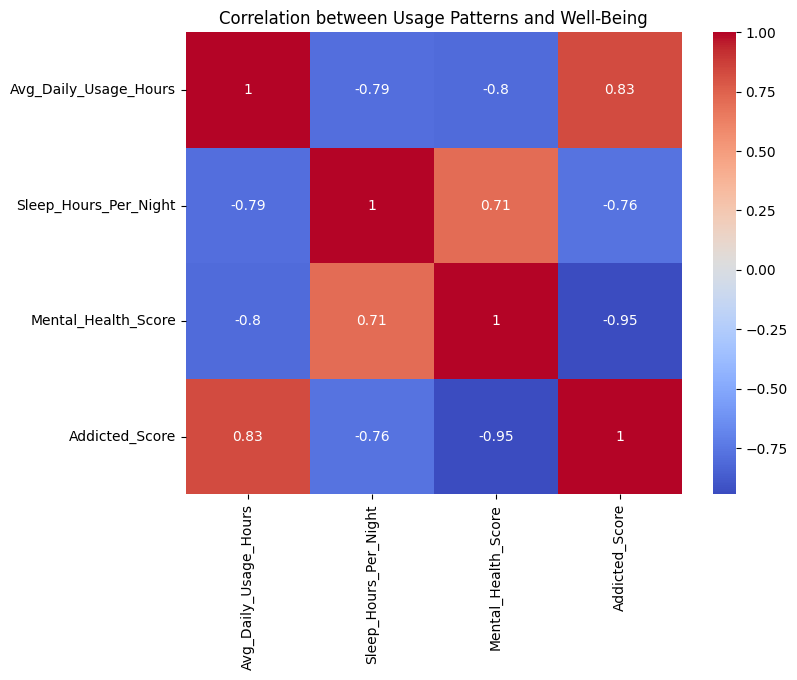

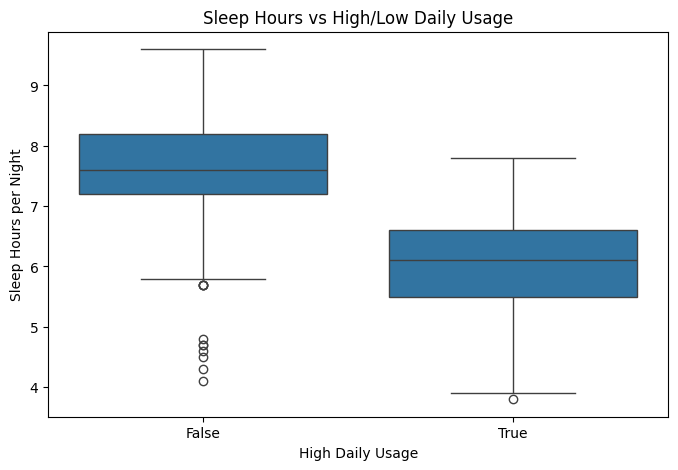

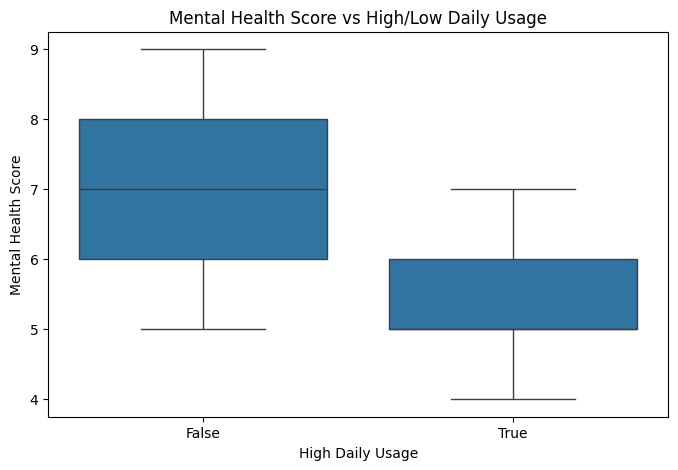


Addiction vs Conflicts:
 Conflicts_Over_Social_Media  0   1    2    3    4   5
Addicted_Score                                       
False                        4  47  202  252    1   0
True                         0   0    2    9  173  15


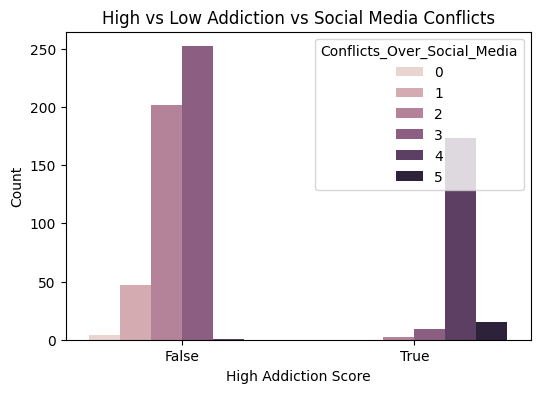

In [ ]:
numeric_cols = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Addicted_Score']
correlation_matrix = df[numeric_cols].corr()
print("Correlation matrix:\n", correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Usage Patterns and Well-Being')
plt.show()

# 2. Compare Sleep & Mental Health for High vs Low Usage
# Define high usage as above median
df['High_Usage'] = df['Avg_Daily_Usage_Hours'] > df['Avg_Daily_Usage_Hours'].median()

# Boxplot: Sleep vs Usage
plt.figure(figsize=(8,5))
sns.boxplot(x='High_Usage', y='Sleep_Hours_Per_Night', data=df)
plt.title('Sleep Hours vs High/Low Daily Usage')
plt.xlabel('High Daily Usage')
plt.ylabel('Sleep Hours per Night')
plt.show()

# Boxplot: Mental Health vs Usage
plt.figure(figsize=(8,5))
sns.boxplot(x='High_Usage', y='Mental_Health_Score', data=df)
plt.title('Mental Health Score vs High/Low Daily Usage')
plt.xlabel('High Daily Usage')
plt.ylabel('Mental Health Score')
plt.show()

# 3. Check relationship between Addiction and Conflicts
conflict_table = pd.crosstab(df['Addicted_Score'] > df['Addicted_Score'].median(),
                             df['Conflicts_Over_Social_Media'])
print("\nAddiction vs Conflicts:\n", conflict_table)

# Optional: Visualize Addiction vs Conflicts
plt.figure(figsize=(6,4))
sns.countplot(x=df['Addicted_Score'] > df['Addicted_Score'].median(), hue=df['Conflicts_Over_Social_Media'])
plt.title('High vs Low Addiction vs Social Media Conflicts')
plt.xlabel('High Addiction Score')
plt.ylabel('Count')
plt.show()

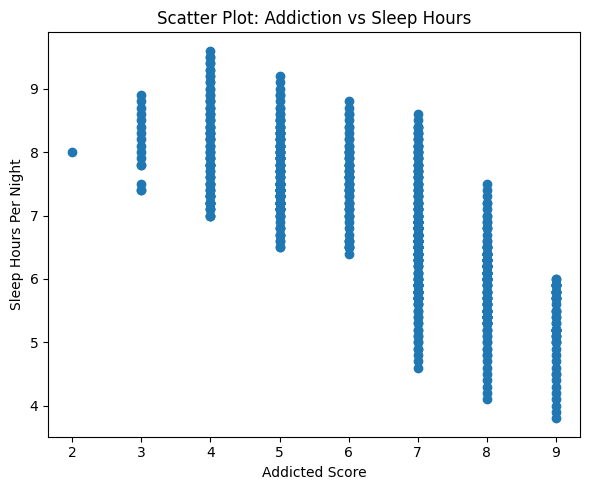

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot: Addiction vs Sleep Hours
plt.figure(figsize=(6,5))
plt.scatter(df["Addicted_Score"], df["Sleep_Hours_Per_Night"])
plt.xlabel("Addicted Score")
plt.ylabel("Sleep Hours Per Night")
plt.title("Scatter Plot: Addiction vs Sleep Hours")
plt.tight_layout()
plt.show()


In [ ]:
drive.mount('/content/drive')
folder_name = 'BA815 competing with data'
csv_file_name = 'Students Social Media Addiction.csv'
# The original shortcut_path was '/content/drive/Shared with me'
# Based on previous successful executions, the file is located in MyDrive.
csv_path = '/content/drive/MyDrive/BA815_Competing_to_Analytics/Students Social Media Addiction.csv'

# The CSV file was not found at the specified path:
# print(f"Attempted path: {csv_path}")
# Please ensure the file is correctly shared and the path is accurate.
# Once you have the correct path, update `csv_path` and uncomment the line below.
df = pd.read_csv(csv_path)


Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BA815_Competing_to_Analytics/Students Social Media Addiction.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


In [ ]:
# Q1: Daily usage by age group & gender
plt.figure(figsize=(10, 6))

custom_palette = {
    'Male': 'lightskyblue',
    'Female': 'lightpink'
}

ax = sns.barplot(
    data=df,
    x='Age',
    y='Avg_Daily_Usage_Hours',
    hue='Gender',
    ci='sd',
    palette=custom_palette,
    edgecolor='black'
)

ax.legend(
    title='Gender',
    title_fontsize=12,
    fontsize=11,
    loc='upper right',
    bbox_to_anchor=(0.98, 1.15),
    frameon=True
)

plt.title('Average Daily Social Media Usage by Age Group & Gender',
          fontsize=15, pad=15, y=1.02)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Avg Daily Usage (hours)', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
#Q2: Which platforms are most associated with addictive behavior and poor well-being?

# Addictive Behavior Composite
addiction_cols = [
    'Addicted_Score',
    'Affects_Academic_Performance',
    'Conflicts_Over_Social_Media'
]

# Poor Well-Being Composite
wellbeing_cols = [
    'Mental_Health_Score',
    'Sleep_Hours_Per_Night',
    'Affects_Academic_Performance',
    'Conflicts_Over_Social_Media'
]

df['Affects_Academic'] = (df['Affects_Academic_Performance'] == 'Yes').astype(int)
df['Has_Conflicts'] = df['Conflicts_Over_Social_Media'].astype(int)

df['Addiction_Index'] = df[['Addicted_Score', 'Affects_Academic', 'Has_Conflicts']].mean(axis=1)
df['Wellbeing_Index'] = df[['Mental_Health_Score', 'Sleep_Hours_Per_Night']].mean(axis=1)
# Note: lower Wellbeing_Index = poorer well-being

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Addictive Behavior
sns.boxplot(ax=axes[0], data=df, x='Most_Used_Platform', y='Addiction_Index', palette='Reds')
axes[0].set_title('Addictive Behavior Index by Platform', fontsize=14, pad=15)
axes[0].set_ylabel('Addiction Index (higher = more addictive)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# 2. Poor Well-Being
sns.boxplot(ax=axes[1], data=df, x='Most_Used_Platform', y='Wellbeing_Index', palette='Blues')
axes[1].set_title('Well-Being Index by Platform', fontsize=14, pad=15)
axes[1].set_ylabel('Well-Being Index (higher = better)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

KeyError: 'Affects_Academic_Performance'

In [ ]:
# Tree map: distribution of users by academic level and platform.Which Academic level is majorly the target?(Demographic)

**Engagement Analysis**

7. What is the optimal engagement duration that maximizes user satisfaction without causing fatigue or detachment?

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4         

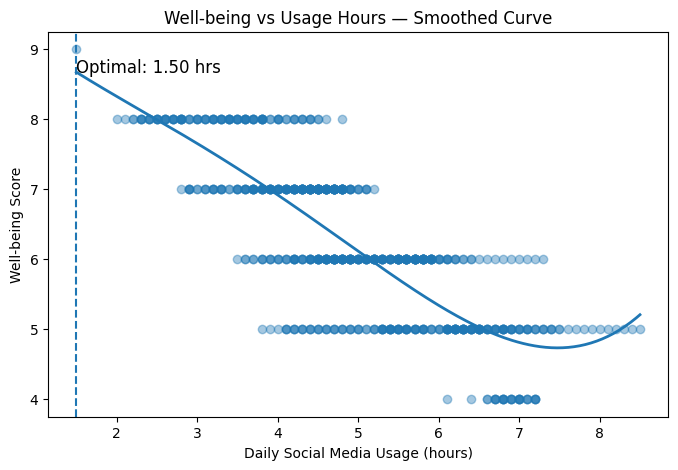

                  Group    n  Optimal_Hours
0               Overall  705       1.500000
1        Gender: Female  353       2.200000
2          Gender: Male  352       1.500000
3    Platform: Facebook  123       2.300000
4   Platform: Instagram  249       2.200000
5   Platform: KakaoTalk   12            NaN
6        Platform: LINE   12            NaN
7    Platform: LinkedIn   21       1.500000
8    Platform: Snapchat   13            NaN
9      Platform: TikTok  154       3.300000
10    Platform: Twitter   30       2.956856
11  Platform: VKontakte   12            NaN
12     Platform: WeChat   15            NaN
13   Platform: WhatsApp   54       5.500000
14    Platform: YouTube   10            NaN

Saved: engagement_optimal_summary.csv


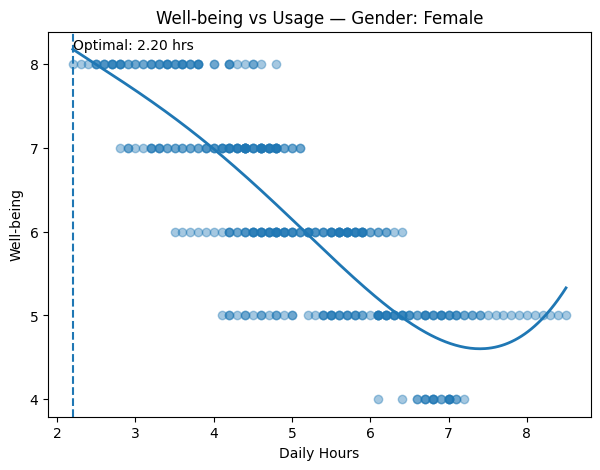

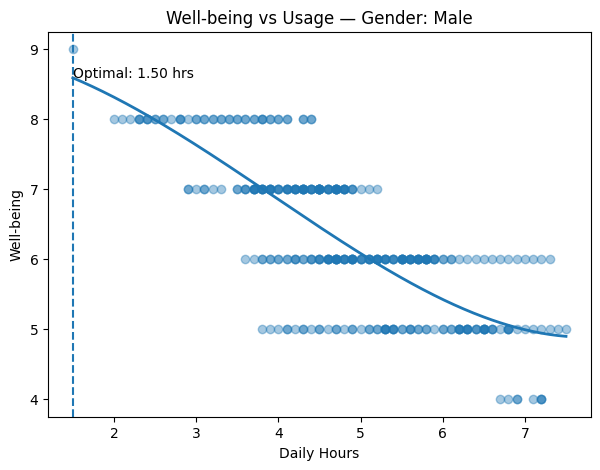

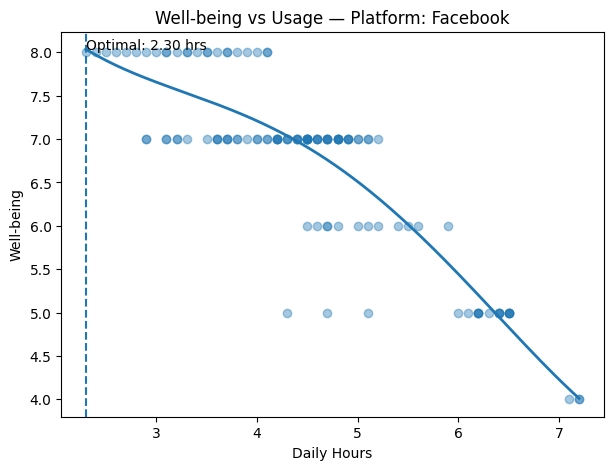

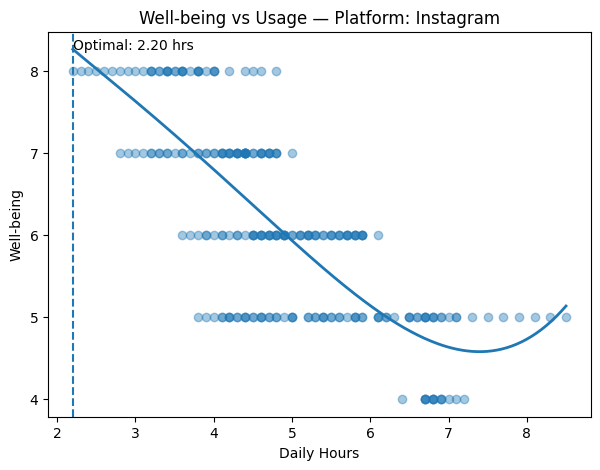

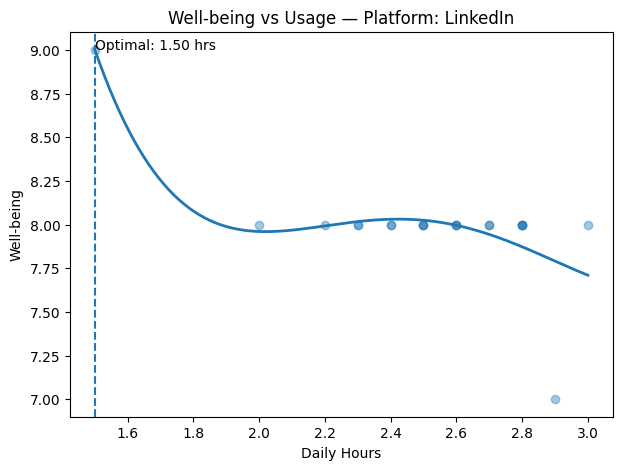

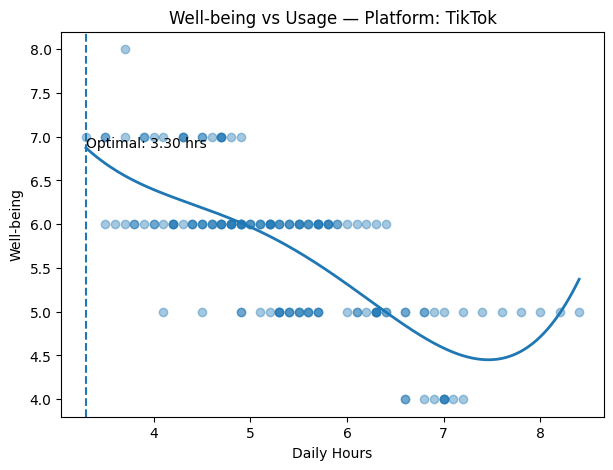

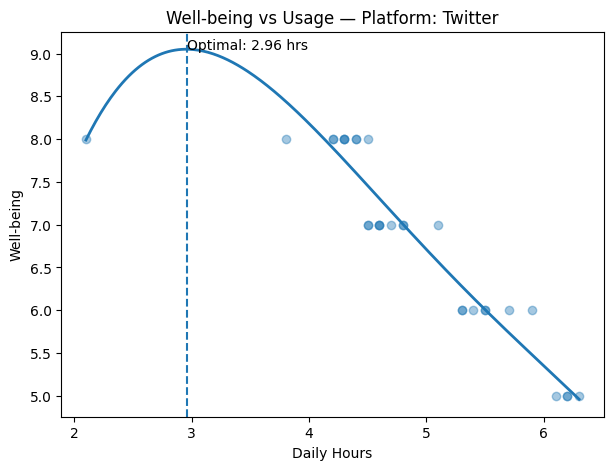

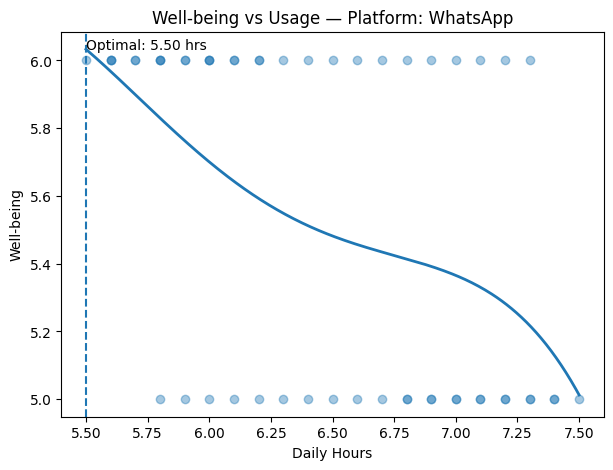

In [ ]:
# --------------------------------------------------
# 1. Setup & Load Dataset
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/BA815_Competing_to_Analytics/Students Social Media Addiction.csv'
df = pd.read_csv(csv_path)
print(df.head())
print(df.shape)

# --------------------------------------------------
# 2. Flexible Column Detection
# --------------------------------------------------
def find_like(df, keywords):
    keywords = [k.lower() for k in keywords]
    for col in df.columns:
        lc = col.lower()
        for k in keywords:
            if k in lc:
                return col
    return None

hour_col     = find_like(df, ["hour", "hours", "usage", "avg_daily_usage"])
well_col     = find_like(df, ["well", "wellbeing", "mental", "happiness", "satisfaction"])
addict_col   = find_like(df, ["addict", "addiction"])
sleep_col    = find_like(df, ["sleep"])
platform_col = find_like(df, ["platform"])
gender_col   = find_like(df, ["gender"])
age_col      = find_like(df, ["age"])

print(f"Detected columns:\nHours = {hour_col}\nWell-being = {well_col}\nPlatform = {platform_col}\nGender = {gender_col}")

# --------------------------------------------------
# 3. Create Well-being Proxy (if needed)
# --------------------------------------------------
if well_col is None:
    proxy_candidates = []
    for key in ["stress", "anxiety", "depress", "mood", "happiness"]:
        c = find_like(df, [key])
        if c:
            proxy_candidates.append(c)

    if proxy_candidates:
        sub = df[proxy_candidates].apply(pd.to_numeric, errors="coerce").dropna(how='all')
        normed = pd.DataFrame()
        for c in proxy_candidates:
            s = sub[c]
            smin, smax = s.min(), s.max()
            if smax == smin:
                normed[c] = 0.5
            else:
                # invert if negative sentiment
                normed[c] = 1 - ((s - smin) / (smax - smin)) if any(k in c.lower() for k in ["stress","anxiety","depress"]) else (s - smin) / (smax - smin)
        df["well_being_proxy"] = normed.mean(axis=1)
        well_col = "well_being_proxy"
        print(f"Created proxy well-being column: {well_col}")

# --------------------------------------------------
# 4. Clean Data
# --------------------------------------------------
df = df.dropna(subset=[hour_col, well_col]).copy()
df[hour_col] = pd.to_numeric(df[hour_col], errors="coerce")
df[well_col] = pd.to_numeric(df[well_col], errors="coerce")
df = df.dropna(subset=[hour_col, well_col])
print("Clean rows:", df.shape[0])

# --------------------------------------------------
# 5. Functions — Optimal Point Estimation
# --------------------------------------------------
def quadratic_optimal(x, y):
    X = np.vstack([x**2, x, np.ones_like(x)]).T
    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    a, b, c = coeffs[0], coeffs[1], coeffs[2]
    opt = None if abs(a) < 1e-8 else -b / (2*a)
    return opt

def smoothed_opt(df_sub, hour_col, well_col):
    x = df_sub[hour_col].astype(float).values
    y = df_sub[well_col].astype(float).values
    if len(x) < 20: return None
    model = make_pipeline(PolynomialFeatures(4), LinearRegression())
    model.fit(x.reshape(-1,1), y)
    xx = np.linspace(x.min(), x.max(), 300)
    yy = model.predict(xx.reshape(-1,1))
    return float(xx[np.argmax(yy)]), float(max(yy))

# --------------------------------------------------
# 6. Overall Estimate + Plot
# --------------------------------------------------
x = df[hour_col].values
y = df[well_col].values

overall_opt, opt_value = smoothed_opt(df, hour_col, well_col)
print(f"\nOptimal usage hours (Overall) = {overall_opt:.2f} hrs/day")

# Plot
xx = np.linspace(x.min(), x.max(), 300)
model = make_pipeline(PolynomialFeatures(4), LinearRegression())
model.fit(x.reshape(-1,1), y)
yy = model.predict(xx.reshape(-1,1))

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4)
plt.plot(xx, yy, linewidth=2)
plt.axvline(overall_opt, linestyle="--")    # visual marker
plt.text(overall_opt, opt_value, f"Optimal: {overall_opt:.2f} hrs", fontsize=12)
plt.xlabel("Daily Social Media Usage (hours)")
plt.ylabel("Well-being Score")
plt.title("Well-being vs Usage Hours — Smoothed Curve")
plt.show()

# --------------------------------------------------
# 7. By Gender / Platform
# --------------------------------------------------
results = []
results.append({"Group":"Overall", "n":len(df), "Optimal_Hours":overall_opt})

# Gender subgroup
if gender_col:
    for g, grp in df.groupby(gender_col):
        opt = smoothed_opt(grp, hour_col, well_col)
        results.append({"Group":f"Gender: {g}", "n":len(grp), "Optimal_Hours":opt[0] if opt else None})

# Platform subgroup
if platform_col:
    for p, grp in df.groupby(platform_col):
        opt = smoothed_opt(grp, hour_col, well_col)
        results.append({"Group":f"Platform: {p}", "n":len(grp), "Optimal_Hours":opt[0] if opt else None})

res_df = pd.DataFrame(results)
print(res_df)
res_df.to_csv("/content/engagement_optimal_summary.csv", index=False)
print("\nSaved: engagement_optimal_summary.csv")

# --------------------------------------------------
# 8. Plot Subgroups
# --------------------------------------------------
def plot_group(df_sub, title):
    x = df_sub[hour_col].astype(float).values
    y = df_sub[well_col].astype(float).values
    if len(x) < 20: return  # skip if too small

    model = make_pipeline(PolynomialFeatures(4), LinearRegression())
    model.fit(x.reshape(-1,1), y)
    xx = np.linspace(x.min(), x.max(), 300)
    yy = model.predict(xx.reshape(-1,1))
    opt, val = smoothed_opt(df_sub, hour_col, well_col)

    plt.figure(figsize=(7,5))
    plt.scatter(x, y, alpha=0.4)
    plt.plot(xx, yy, linewidth=2)
    if opt:
        plt.axvline(opt, linestyle='--')
        plt.text(opt, val, f"Optimal: {opt:.2f} hrs", fontsize=10)
    plt.title(title)
    plt.xlabel("Daily Hours")
    plt.ylabel("Well-being")
    plt.show()

# Plot gender & platforms
if gender_col:
    for g, grp in df.groupby(gender_col):
        plot_group(grp, f"Well-being vs Usage — Gender: {g}")

if platform_col:
    for p, grp in df.groupby(platform_col):
        plot_group(grp, f"Well-being vs Usage — Platform: {p}")

Columns: ['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'high_addiction', 'short_sleep']
Cleaned shape: (705, 15)
   Avg_Daily_Usage_Hours  Mental_Health_Score  Addicted_Score  \
0                    5.2                    6               8   
1                    2.1                    8               3   
2                    6.0                    5               9   
3                    3.0                    7               4   
4                    4.5                    6               7   

   Sleep_Hours_Per_Night Most_Used_Platform  Gender  
0                    6.5          Instagram  Female  
1                    7.5            Twitter    Male  
2                    5.0             TikTok  Female  
3                    7.0            YouTube    Male  
4           

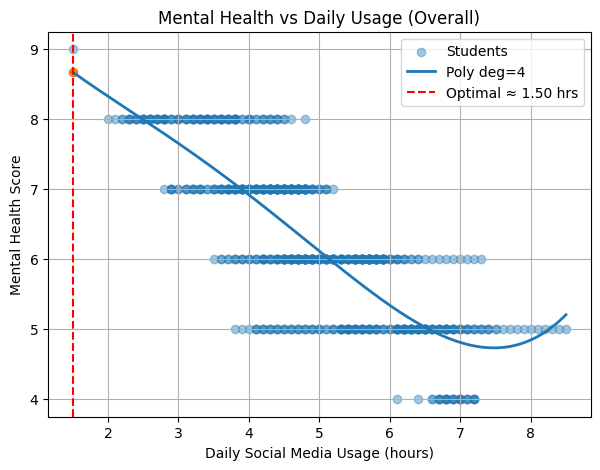

[Overall] Predicting the highest usage time for mental health ≈ 1.50 hours/day


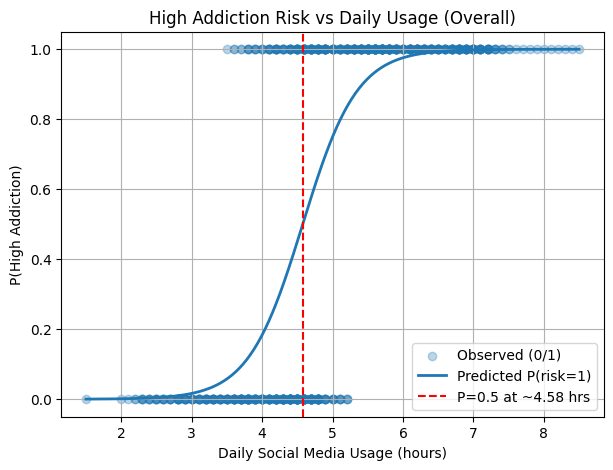

[Overall] The critical point of high risk of addiction (Addicted_Score ≥ 7) is P=0.5 ≈ 4.58 hours/day


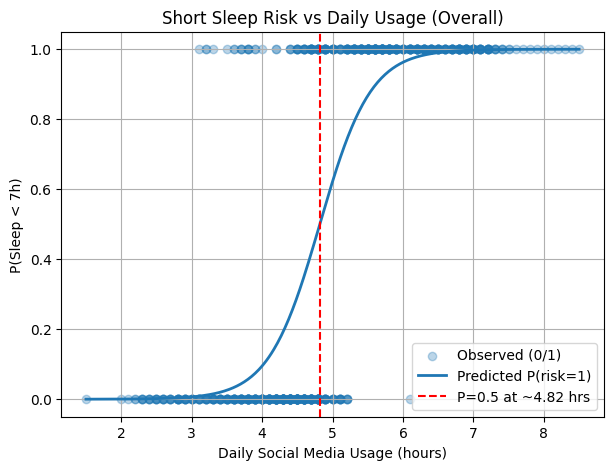

[Overall] The critical point of lacking of sleep (sleep < 7 hours) is P=0.5 ≈ 4.82 hours/day


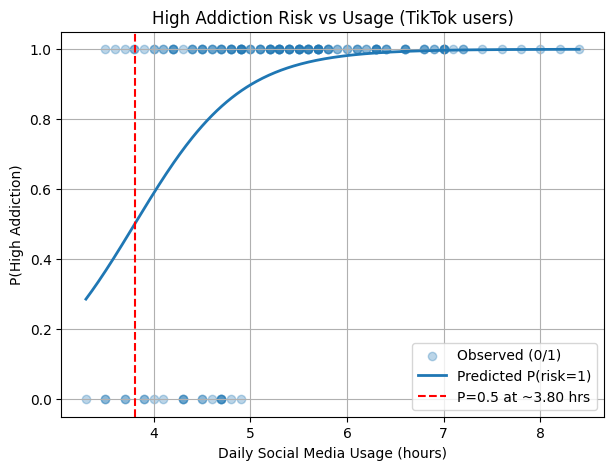

[TikTok] The critical point of high addiction risk is P=0.5 ≈ 3.80 hours/day (sample size: 154)


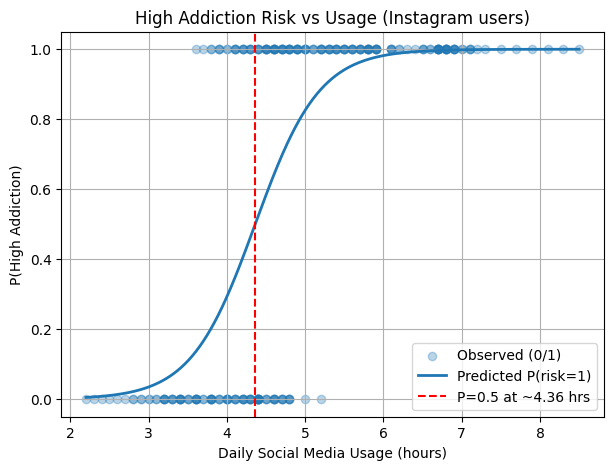

[Instagram] The critical point of high addiction risk is P=0.5 ≈ 4.36 hours/day (sample size: 249)

=== Summary of Key Thresholds ===
                               Metric     Hours
0  Overall_Optimal_MentalHealth_Hours  1.500000
1         Overall_Addiction_P50_Hours  4.577041
2        Overall_ShortSleep_P50_Hours  4.819200
3          TikTok_Addiction_P50_Hours  3.803285
4       Instagram_Addiction_P50_Hours  4.362205
Saved to /content/engagement_threshold_summary.csv


In [ ]:
# ==================================================
# 0. Imports & Load Data
# ==================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression

# ==================================================
# 1. critical columns
# ==================================================
HOURS_COL   = 'Avg_Daily_Usage_Hours'
WELL_COL    = 'Mental_Health_Score'
ADDICT_COL  = 'Addicted_Score'
SLEEP_COL   = 'Sleep_Hours_Per_Night'
PLATFORM_COL= 'Most_Used_Platform'
GENDER_COL  = 'Gender'

# check columns
print("Columns:", df.columns.tolist())

# data cleaning: only reserve critical columns
df = df.copy()
df[HOURS_COL] = pd.to_numeric(df[HOURS_COL], errors='coerce')
df[WELL_COL]  = pd.to_numeric(df[WELL_COL], errors='coerce')
df[ADDICT_COL]= pd.to_numeric(df[ADDICT_COL], errors='coerce')
df[SLEEP_COL] = pd.to_numeric(df[SLEEP_COL], errors='coerce')

df = df.dropna(subset=[HOURS_COL, WELL_COL, ADDICT_COL, SLEEP_COL])

print("Cleaned shape:", df.shape)
print(df[[HOURS_COL, WELL_COL, ADDICT_COL, SLEEP_COL, PLATFORM_COL, GENDER_COL]].head())

# ==================================================
# 2. Mental health vs Usage hours：Multinomial regression + curve + optimal point
# ==================================================
def fit_polynomial_and_plot(df_sub, x_col, y_col, degree=4, title=''):
    """
    Fit y to poly(x), plot a scatter plot and smooth curve,
    and backfeed the results to the x* and y* values ​​that maximize y within the observation range.
    """
    x = df_sub[x_col].values.astype(float)
    y = df_sub[y_col].values.astype(float)

    # Fitting polynomial
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x.reshape(-1, 1), y)

    # Make a smooth curve
    xx = np.linspace(x.min(), x.max(), 400)
    yy = model.predict(xx.reshape(-1, 1))

    # Find the location of the maximum value on the curve (within the observation range)
    idx_max = np.argmax(yy)
    x_opt = float(xx[idx_max])
    y_opt = float(yy[idx_max])

    # Plot the results
    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.4, label='Students')
    plt.plot(xx, yy, linewidth=2, label=f'Poly deg={degree}')
    plt.axvline(x_opt, linestyle='--', color='red', label=f'Optimal ≈ {x_opt:.2f} hrs')
    plt.scatter([x_opt], [y_opt], marker='o')
    plt.xlabel('Daily Social Media Usage (hours)')
    plt.ylabel('Mental Health Score')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

    return x_opt, y_opt

overall_x_opt, overall_y_opt = fit_polynomial_and_plot(
    df,
    HOURS_COL,
    WELL_COL,
    degree=4,
    title='Mental Health vs Daily Usage (Overall)'
)

print(f"[Overall] Predicting the highest usage time for mental health ≈ {overall_x_opt:.2f} hours/day")

# ==================================================
# 3. Logistic Regression：High addiction / Lack of sleep vs Usage hours
# ==================================================
def logistic_threshold_and_plot(df_sub, x_col, y_binary, title, label_y,
                                hours_range=None):
    """
    Perform logistic regression on y_binary ~ x_col:

- Return: the critical point where probability = 0.5 (hours)

- Plot: probability vs. usage hours curve
    """
    sub = df_sub[[x_col, y_binary]].dropna().copy()
    x = sub[x_col].values.reshape(-1, 1).astype(float)
    y = sub[y_binary].values.astype(int)

    if hours_range is None:
        h_min, h_max = x.min(), x.max()
    else:
        h_min, h_max = hours_range

    # Logistic Regression
    clf = LogisticRegression(max_iter=2000)
    clf.fit(x, y)

    # Predicting smooth lines
    xs = np.linspace(h_min, h_max, 400).reshape(-1, 1)
    probs = clf.predict_proba(xs)[:, 1]

    # The critical point for probability = 0.5: w0 + w1*x = 0 → x = -w0/w1
    w0 = clf.intercept_[0]
    w1 = clf.coef_[0][0]
    threshold = None
    if w1 != 0:
        threshold = -w0 / w1

    # Plot results
    plt.figure(figsize=(7, 5))
    plt.scatter(sub[x_col], y, alpha=0.3, label='Observed (0/1)')
    plt.plot(xs, probs, linewidth=2, label='Predicted P(risk=1)')
    if threshold is not None and h_min <= threshold <= h_max:
        plt.axvline(threshold, linestyle='--', color='red',
                    label=f'P=0.5 at ~{threshold:.2f} hrs')
    plt.xlabel('Daily Social Media Usage (hours)')
    plt.ylabel(label_y)
    plt.ylim(-0.05, 1.05)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

    return threshold

# 3.1 High risk of addiction：Addicted_Score >= 7
HIGH_ADDICTION_THRESHOLD = 7
df['high_addiction'] = (df[ADDICT_COL] >= HIGH_ADDICTION_THRESHOLD).astype(int)

thr_add_overall = logistic_threshold_and_plot(
    df,
    HOURS_COL,
    'high_addiction',
    title='High Addiction Risk vs Daily Usage (Overall)',
    label_y='P(High Addiction)'
)
print(f"[Overall] The critical point of high risk of addiction (Addicted_Score ≥ {HIGH_ADDICTION_THRESHOLD}) is P=0.5 ≈ {thr_add_overall:.2f} hours/day")

# 3.2 Lack of sleep：Sleep_Hours_Per_Night < 7
SHORT_SLEEP_THRESHOLD = 7
df['short_sleep'] = (df[SLEEP_COL] < SHORT_SLEEP_THRESHOLD).astype(int)

thr_sleep_overall = logistic_threshold_and_plot(
    df,
    HOURS_COL,
    'short_sleep',
    title='Short Sleep Risk vs Daily Usage (Overall)',
    label_y='P(Sleep < 7h)'
)
print(f"[Overall] The critical point of lacking of sleep (sleep < {SHORT_SLEEP_THRESHOLD} hours) is P=0.5 ≈ {thr_sleep_overall:.2f} hours/day")

# ==================================================
# 4. Platform Difference：User addiction risk of TikTok / Instagram
# ==================================================
def addiction_by_platform(df, platform_name):
    sub = df[df[PLATFORM_COL] == platform_name].copy()
    if sub.shape[0] < 30:
        print(f"{platform_name}: The sample size is too small, so we will skip this step.")
        return None

    thr = logistic_threshold_and_plot(
        sub,
        HOURS_COL,
        'high_addiction',
        title=f'High Addiction Risk vs Usage ({platform_name} users)',
        label_y='P(High Addiction)'
    )

    print(f"[{platform_name}] The critical point of high addiction risk is P=0.5 ≈ {thr:.2f} hours/day (sample size: {sub.shape[0]})")
    return thr

tik_tok_thr = addiction_by_platform(df, 'TikTok')
ig_thr      = addiction_by_platform(df, 'Instagram')

# ==================================================
# 5. Summary（output as CSV）
# ==================================================
summary_rows = [
    ['Overall_Optimal_MentalHealth_Hours', overall_x_opt],
    ['Overall_Addiction_P50_Hours', thr_add_overall],
    ['Overall_ShortSleep_P50_Hours', thr_sleep_overall],
    ['TikTok_Addiction_P50_Hours', tik_tok_thr],
    ['Instagram_Addiction_P50_Hours', ig_thr],
]

summary_df = pd.DataFrame(summary_rows, columns=['Metric', 'Hours'])
print("\n=== Summary of Key Thresholds ===")
print(summary_df)

summary_df.to_csv('/content/engagement_threshold_summary.csv', index=False)
print("Saved to /content/engagement_threshold_summary.csv")